In [1]:
import numpy as np
import pandas as pd

# Set seed for reproducibility
np.random.seed(42)
n = 1000

data = {
    'Customer_ID': [f'CUST-{i:04d}' for i in range(1, n + 1)],
    'Tenure_Months': np.random.randint(1, 48, n),
    'Monthly_Charges': np.random.uniform(29.0, 199.0, n).round(2),
    'Support_Tickets': np.random.randint(0, 10, n),
    'Contract_Type': np.random.choice(
        ['Month-to-Month', 'One-Year', 'Two-Year'], n, p=[0.5, 0.3, 0.2]
    ),
    'Payment_Method': np.random.choice(
        ['Credit Card', 'Bank Transfer', 'Electronic Check'], n
    ),
}

df = pd.DataFrame(data)

# Churn logic: high tickets + month-to-month contracts trigger higher churn risk
churn_prob = (
    0.1
    + (df['Support_Tickets'] * 0.08)
    + (df['Contract_Type'] == 'Month-to-Month') * 0.25
    - (df['Tenure_Months'] * 0.005)
)
churn_prob = np.clip(churn_prob, 0.05, 0.90)
df['Churn'] = (np.random.rand(n) < churn_prob).astype(int)

df.to_csv('customer_churn_data.csv', index=False)
df.head()

,Customer_ID,Tenure_Months,Monthly_Charges,Support_Tickets,Contract_Type,Payment_Method,Churn
0,CUST-0001,39,83.80,5,Month-to-Month,Credit Card,1
1,CUST-0002,29,166.68,1,One-Year,Electronic Check,0
2,CUST-0003,15,72.29,6,Two-Year,Electronic Check,0
3,CUST-0004,43,144.86,2,Month-to-Month,Electronic Check,0
4,CUST-0005,8,158.24,2,Month-to-Month,Credit Card,0


In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

# One-hot encode categorical features
X = pd.get_dummies(
    df.drop(columns=['Customer_ID', 'Churn']), drop_first=True
)
y = df['Churn']

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train a Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions & Evaluation
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print('ROC-AUC Score:', round(roc_auc_score(y_test, y_prob), 4))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

ROC-AUC Score: 0.7723

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.73      0.74       117
           1       0.63      0.66      0.65        83

    accuracy                           0.70       200
   macro avg       0.69      0.69      0.69       200
weighted avg       0.70      0.70      0.70       200



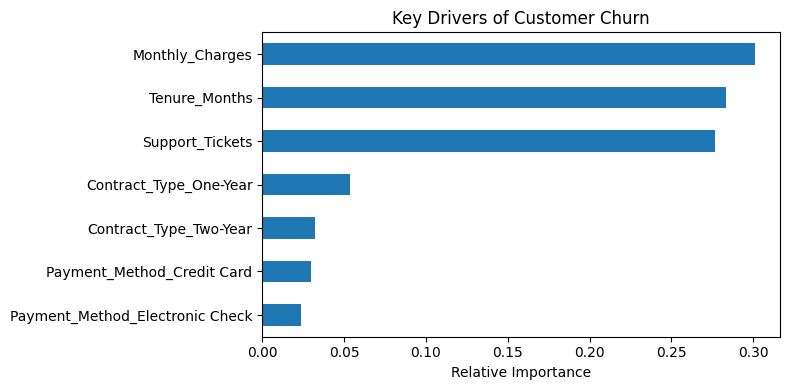

Total Monthly Recurring Revenue at Risk: $10,361.80


In [3]:
import matplotlib.pyplot as plt

# Feature importance plot
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(
    ascending=True
)

plt.figure(figsize=(8, 4))
importances.plot(kind='barh', color='#1f77b4')
plt.title('Key Drivers of Customer Churn')
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.savefig('churn_drivers.png')
plt.show()

# Calculate revenue at risk in the test set
test_customers = df.iloc[X_test.index].copy()
test_customers['Predicted_Churn'] = y_pred
revenue_at_risk = test_customers[test_customers['Predicted_Churn'] == 1][
    'Monthly_Charges'
].sum()
print(f'Total Monthly Recurring Revenue at Risk: ${revenue_at_risk:,.2f}')